In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
TRAIN_PATH = "../data/classification/train"
VAL_PATH = "../data/classification/val"

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1750 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [3]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


In [4]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [5]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.0389 - loss: 4.1283 - val_accuracy: 0.0400 - val_loss: 3.2494
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.0509 - loss: 3.7548 - val_accuracy: 0.0400 - val_loss: 3.2556
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.0377 - loss: 3.6871 - val_accuracy: 0.0400 - val_loss: 3.2513
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.0371 - loss: 3.5573 - val_accuracy: 0.0400 - val_loss: 3.2698
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.0371 - loss: 3.5209 - val_accuracy: 0.0373 - val_loss: 3.2562
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.0354 - loss: 3.4813 - val_accuracy: 0.0427 - val_loss: 3.2629
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.0389 - loss: 3.4413 - val_accuracy: 0.0427 - val_loss: 3.2522
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.0411 - loss: 3.4002 - val_accuracy: 0.0400 - va

In [8]:
model.save("../models/efficientnet_model.h5")
print("EfficientNet Model Saved ✅")

EfficientNet Model Saved ✅


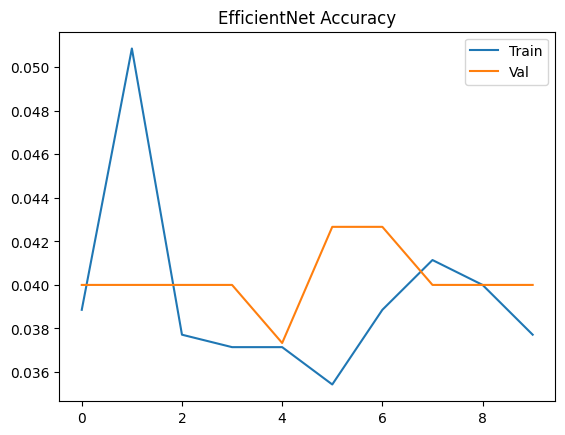

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("EfficientNet Accuracy")
plt.legend(["Train","Val"])
plt.show()